# Perform EDA : Exploratory Data Analysis

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [18]:
# Load Dataset
df = pd.read_csv(r"titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Dataset Information
print("\nDataset Info:")
print(df.info())




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [5]:
# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())




Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [6]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
# count of unique values in each feature
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Gender           2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [8]:
# -------------------------------
# Data Cleaning
# -------------------------------

# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop(columns=['Cabin'], inplace=True) 

# Verify missing values 
print("\nMissing Values After Cleaning:") 
print(df.isnull().sum())


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [9]:
# Verify missing values
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### EDA Visualizations

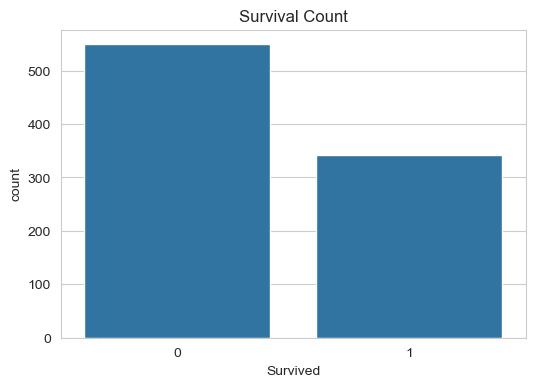

In [15]:
sns.set_style("whitegrid") 
# Survival Count 
plt.figure(figsize=(6,4)) 
sns.countplot(x='Survived', data=df) 
plt.title("Survival Count") 
plt.show()


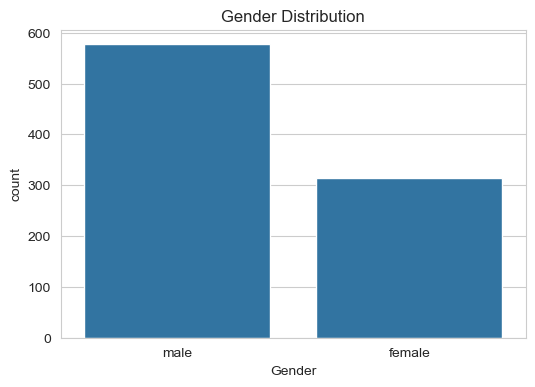

In [19]:
# Gender Distribution 
plt.figure(figsize=(6,4)) 
sns.countplot(x='Gender', data=df) 
plt.title("Gender Distribution") 
plt.show()

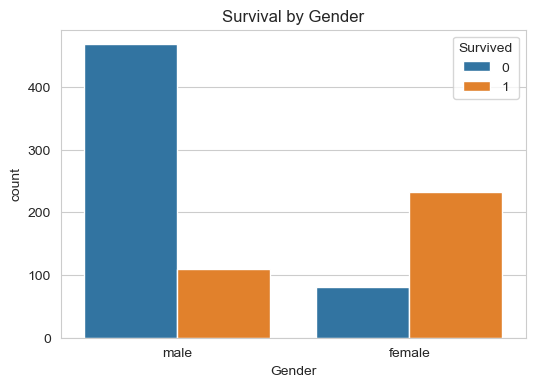

In [20]:
# Survival by Gender 
plt.figure(figsize=(6,4)) 
sns.countplot(x='Gender', hue='Survived', data=df) 
plt.title("Survival by Gender") 
plt.show()

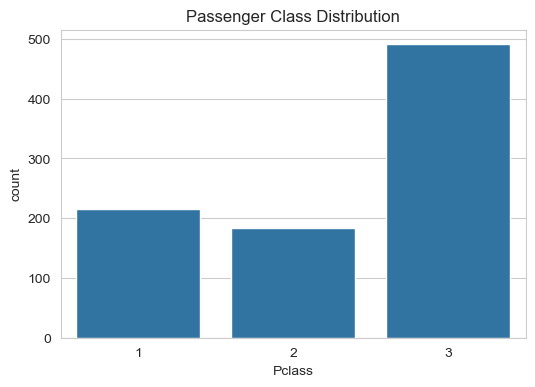

In [21]:
# Passenger Class Distribution 
plt.figure(figsize=(6,4)) 
sns.countplot(x='Pclass', data=df) 
plt.title("Passenger Class Distribution") 
plt.show()

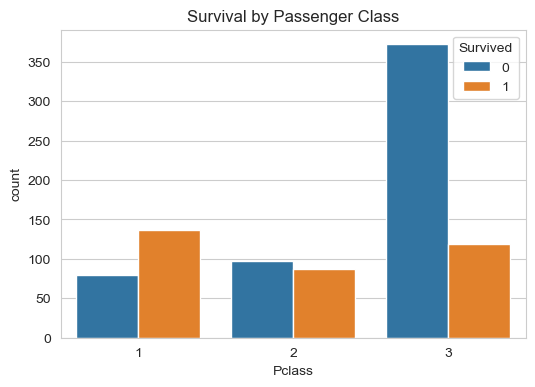

In [23]:
# Survival by Passenger Class 
plt.figure(figsize=(6,4)) 
sns.countplot(x='Pclass', hue='Survived', data=df) 
plt.title("Survival by Passenger Class") 
plt.show()




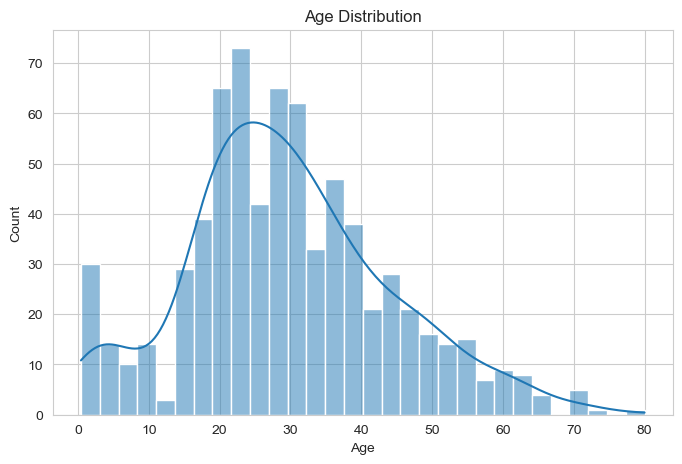

In [24]:



# Age Distribution 
plt.figure(figsize=(8,5)) 
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution") 
plt.show()

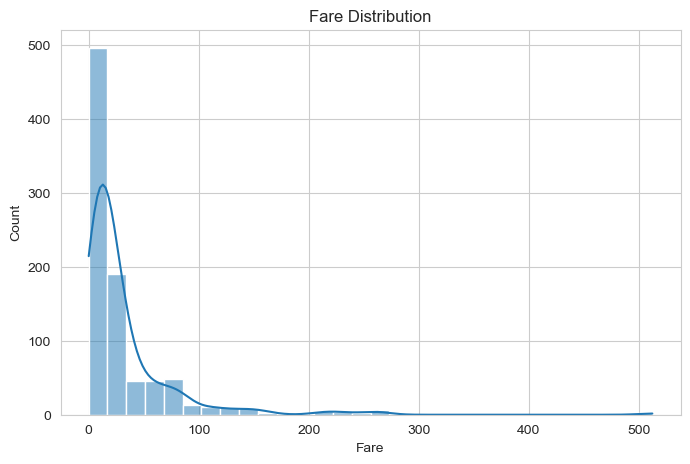

In [25]:
# Fare Distribution 
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution") 
plt.show()


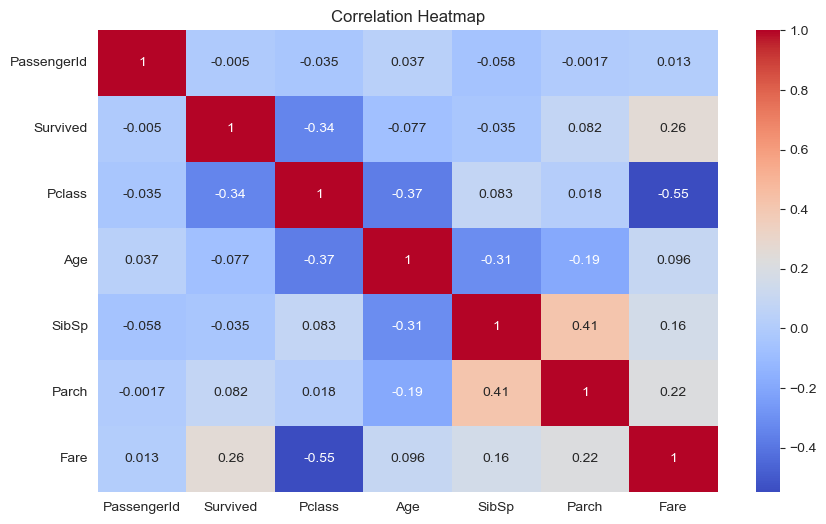

In [27]:
# Correlation Heatmap 
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number']) 
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm') 
plt.title("Correlation Heatmap") 
plt.show()


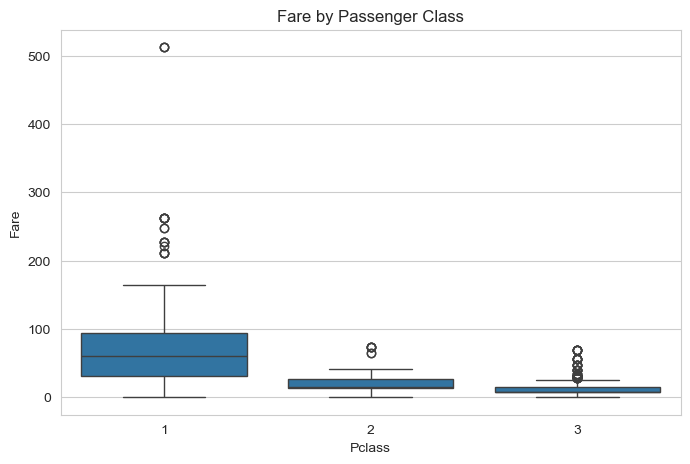

In [28]:
# Boxplot for Fare vs Class 
plt.figure(figsize=(8,5)) 
sns.boxplot(x='Pclass', y='Fare', data=df) 
plt.title("Fare by Passenger Class") 
plt.show()





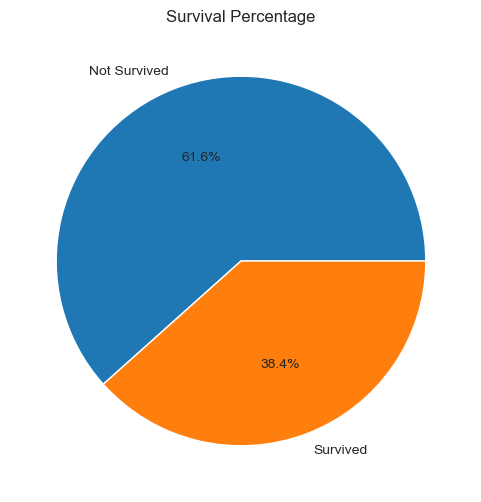

In [29]:
# Pie Chart of Survival 
survival_counts = df['Survived'].value_counts() 
plt.figure(figsize=(6,6))
plt.pie( 
    survival_counts,
    labels=['Not Survived', 'Survived'],
    autopct='%1.1f%%' 
)
plt.title("Survival Percentage") 
plt.show()




In [31]:
print("\nKey Insights:") 
print("1. Female passengers had higher survival rates.")
print("2. First-class passengers survived more frequently.") 
print("3. Higher ticket fares correlated with survival.") 
print("4. Younger passengers had slightly better survival chances.") 
print("\nEDA Completed Successfully.")




Key Insights:
1. Female passengers had higher survival rates.
2. First-class passengers survived more frequently.
3. Higher ticket fares correlated with survival.
4. Younger passengers had slightly better survival chances.

EDA Completed Successfully.
